# Assignment 1: Statistical Interpretation and Exploratory Data Analysis  
## Course: 5CS037 – Concepts and Technologies of AI  
## Student Name: Prajita Banjara  


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem 1A: Single Year HDI Exploration (2022)
### Task 1: Load Dataset


In [42]:
df = pd.read_csv("/content/Human_Development_Index_Dataset.csv", encoding='latin1')
df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


### Task 2: Extract Latest Year (2022)
The dataset was filtered to include only observations from the year 2022.


In [17]:
hdi_2022_df = df[df['year'] == 2022]
hdi_2022_df.head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


## Problem 2: Advanced HDI Exploration


### Task 1: South Asia Subset Creation
The dataset was filtered to include only South Asian countries as defined in the assignment.


In [18]:
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

south_asia_df = df[df['country'].isin(south_asia_countries)]

south_asia_df.head()


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [19]:
south_asia_df.to_csv("HDI_SouthAsia.csv", index=False)


### Task 2: Composite Development Score
A composite score was calculated using Life Expectancy and GNI per Capita indices.


In [20]:
south_asia_df['Composite Score'] = (
    0.30 * south_asia_df['life_expectancy'] +
    0.30 * south_asia_df['gross_inc_percap']
)

south_asia_df_sorted = south_asia_df.sort_values(
    by='Composite Score', ascending=False
)

south_asia_df_sorted[['country', 'Composite Score']].head()

/tmp/ipython-input-856099927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  south_asia_df['Composite Score'] = (


,country,Composite Score
3530,Maldives,5678.289357
3527,Maldives,5628.012408
3526,Maldives,5440.721295
3525,Maldives,5266.375503
3524,Maldives,5097.397866


In [21]:
print(south_asia_df.columns)

Index(['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy',
       'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m',
       'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m',
       'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m',
       'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
       'gender_development', 'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons', 'Composite Score'],
      dtype='object')


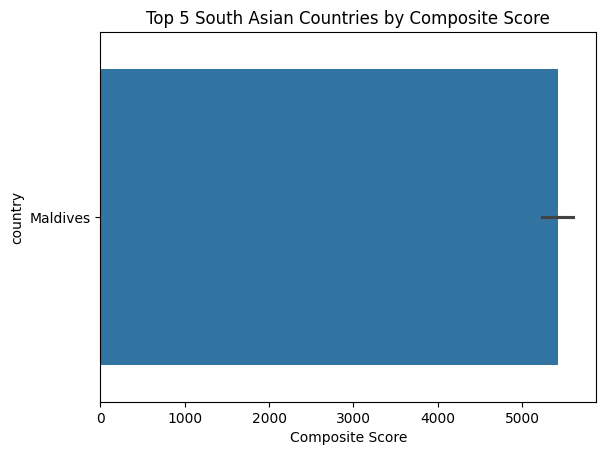

In [22]:
top5 = south_asia_df_sorted.head(5)

plt.figure()
sns.barplot(data=top5, x='Composite Score', y='country')
plt.title("Top 5 South Asian Countries by Composite Score")
plt.show()


##TASK 3: Outlier Detection

In [23]:
Q1 = south_asia_df['hdi'].quantile(0.25)
Q3 = south_asia_df['hdi'].quantile(0.75)
IQR = Q3 - Q1

outliers = south_asia_df[
    (south_asia_df['hdi'] < Q1 - 1.5 * IQR) |
    (south_asia_df['hdi'] > Q3 + 1.5 * IQR)
]

outliers[['country', 'hdi']]


,country,hdi


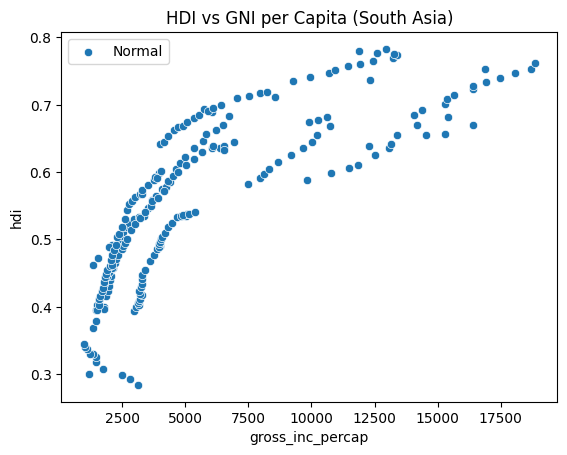

In [24]:
plt.figure()
sns.scatterplot(
    data=south_asia_df,
    x='gross_inc_percap',
    y='hdi',
    label='Normal'
)

sns.scatterplot(
    data=outliers,
    x='gross_inc_percap',
    y='hdi',
    color='red',
    label='Outliers'
)

plt.title("HDI vs GNI per Capita (South Asia)")
plt.legend()
plt.show()

##TASK 4: Metric Relationships

In [25]:
metrics = ['life_expectancy', 'gender_development']

for metric in metrics:
    corr = south_asia_df[metric].corr(south_asia_df['hdi'])
    print(f"Correlation between {metric} and HDI: {corr}")

Correlation between life_expectancy and HDI: 0.9587610559043978
Correlation between gender_development and HDI: 0.865621005012754


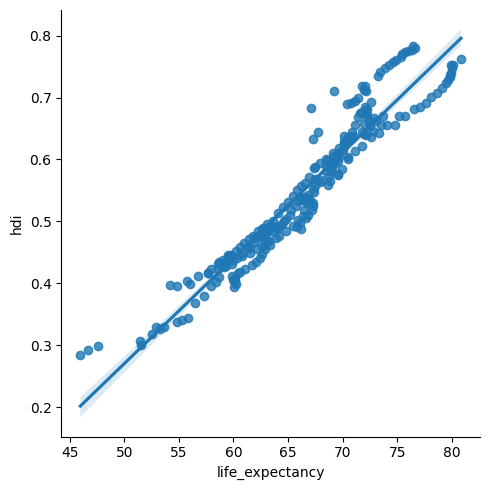

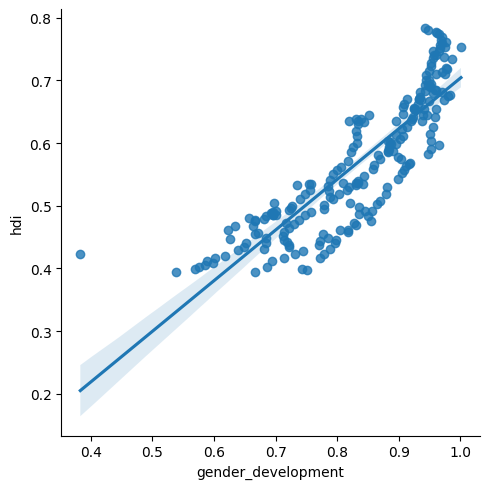

In [26]:
for metric in metrics:
    sns.lmplot(
        data=south_asia_df,
        x=metric,
        y='hdi'
    )


##TASK 5: GNI–HDI Gap

In [27]:
south_asia_df['GNI_HDI_Gap'] = (
    south_asia_df['gross_inc_percap'] - south_asia_df['hdi']
)

gap_sorted = south_asia_df.sort_values(by='GNI_HDI_Gap')

gap_sorted[['country', 'GNI_HDI_Gap']]

/tmp/ipython-input-2670880361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  south_asia_df['GNI_HDI_Gap'] = (


,country,GNI_HDI_Gap
11,Afghanistan,980.789554
10,Afghanistan,1047.002686
9,Afghanistan,1121.985570
4,Afghanistan,1201.710488
8,Afghanistan,1226.964565
...,...,...
3498,Maldives,NaN
3499,Maldives,NaN
3500,Maldives,NaN
3501,Maldives,NaN


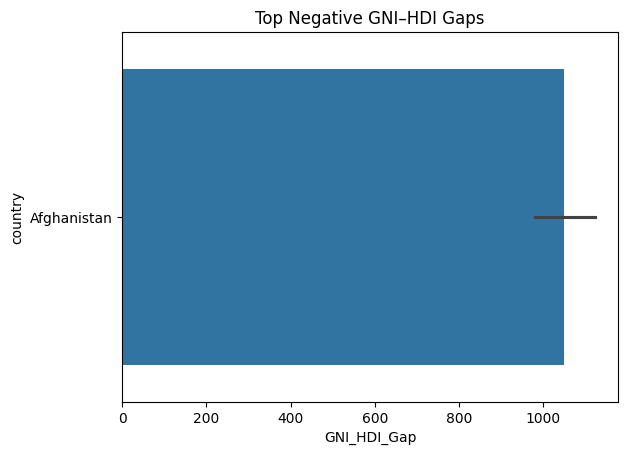

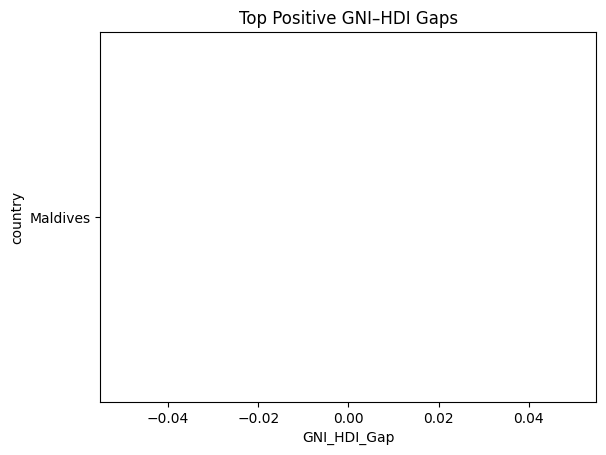

In [28]:
top_gap = gap_sorted.head(3)
bottom_gap = gap_sorted.tail(3)

plt.figure()
sns.barplot(data=top_gap, x='GNI_HDI_Gap', y='country')
plt.title("Top Negative GNI–HDI Gaps")
plt.show()

plt.figure()
sns.barplot(data=bottom_gap, x='GNI_HDI_Gap', y='country')
plt.title("Top Positive GNI–HDI Gaps")
plt.show()


## Problem 3: Comparative Regional Analysis — South Asia vs Middle East


### Task 1: Regional Subset Creation
South Asia and Middle East subsets were created using predefined country lists.


In [29]:
south_asia = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

df_2020_2022 = df[df['year'].isin([2020, 2021, 2022])]
south_asia_2020_22 = df_2020_2022[df_2020_2022['country'].isin(south_asia)]
middle_east_2020_22 = df_2020_2022[df_2020_2022['country'].isin(middle_east)]

south_asia_2020_22.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_2020_22.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

##TASK 2: Descriptive Statistics

In [30]:
sa_stats = south_asia_2020_22['hdi'].agg(['mean', 'std'])
me_stats = middle_east_2020_22['hdi'].agg(['mean', 'std'])

sa_stats, me_stats


(mean    0.639583
 std     0.098273
 Name: hdi, dtype: float64,
 mean    0.788909
 std     0.141295
 Name: hdi, dtype: float64)

##TASK 3: Top & Bottom Performers

In [31]:
sa_top = south_asia_2020_22.sort_values('hdi', ascending=False).head(3)
sa_bottom = south_asia_2020_22.sort_values('hdi').head(3)

me_top = middle_east_2020_22.sort_values('hdi', ascending=False).head(3)
me_bottom = middle_east_2020_22.sort_values('hdi').head(3)


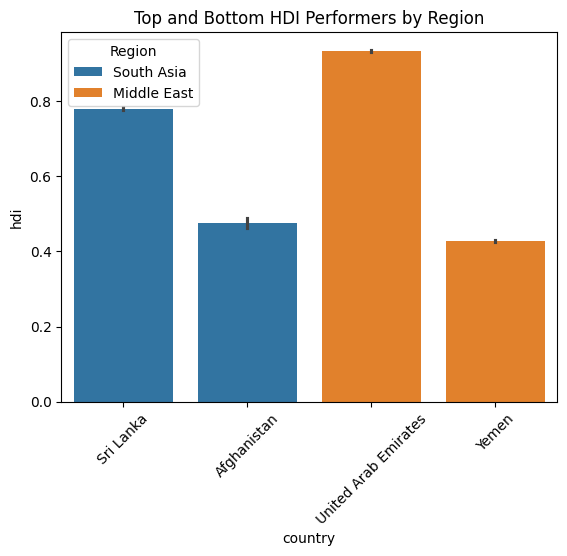

In [32]:
compare_df = pd.concat([
    sa_top.assign(Region="South Asia"),
    sa_bottom.assign(Region="South Asia"),
    me_top.assign(Region="Middle East"),
    me_bottom.assign(Region="Middle East")
])

plt.figure()
sns.barplot(data=compare_df, x='country', y='hdi', hue='Region')
plt.xticks(rotation=45)
plt.title("Top and Bottom HDI Performers by Region")
plt.show()


##TASK 4: Metric Comparisons (Grouped Bars)

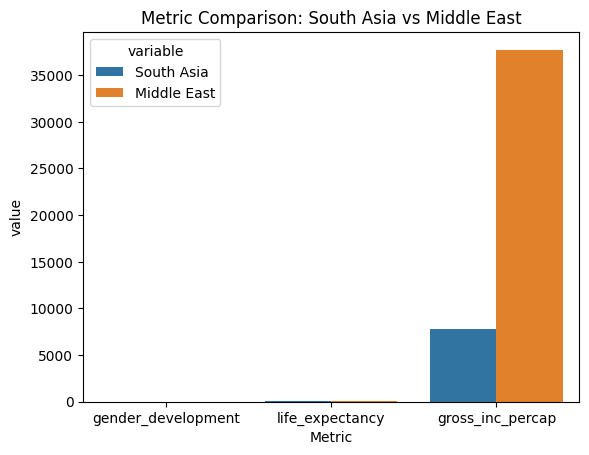

In [33]:
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

sa_means = south_asia_2020_22.groupby('year')[metrics].mean().mean()
me_means = middle_east_2020_22.groupby('year')[metrics].mean().mean()

metric_df = pd.DataFrame({
    'South Asia': sa_means,
    'Middle East': me_means
}).reset_index().rename(columns={'index': 'Metric'})

plt.figure()
sns.barplot(data=metric_df.melt(id_vars='Metric'),
            x='Metric', y='value', hue='variable')
plt.title("Metric Comparison: South Asia vs Middle East")
plt.show()

##TASK 5: HDI Disparity (Range & CV)

In [34]:
def disparity_stats(df):
    mean = df['hdi'].mean()
    std = df['hdi'].std()
    return {
        "Range": df['hdi'].max() - df['hdi'].min(),
        "CV": std / mean
    }

disparity_stats(south_asia_2020_22), disparity_stats(middle_east_2020_22)


({'Range': 0.321, 'CV': np.float64(0.1536520924690084)},
 {'Range': 0.5130000000000001, 'CV': np.float64(0.17910145193048382)})

##TASK 6: Correlation Analysis

In [35]:
for region, data in {
    "South Asia": south_asia_2020_22,
    "Middle East": middle_east_2020_22
}.items():
    print(region)
    print("Life Expectancy:", data['life_expectancy'].corr(data['hdi']))
    print("Gender Development:", data['gender_development'].corr(data['hdi']))

South Asia
Life Expectancy: 0.9387641385416623
Gender Development: 0.8742177004831327
Middle East
Life Expectancy: 0.9331227568940162
Gender Development: 0.9356697525724119


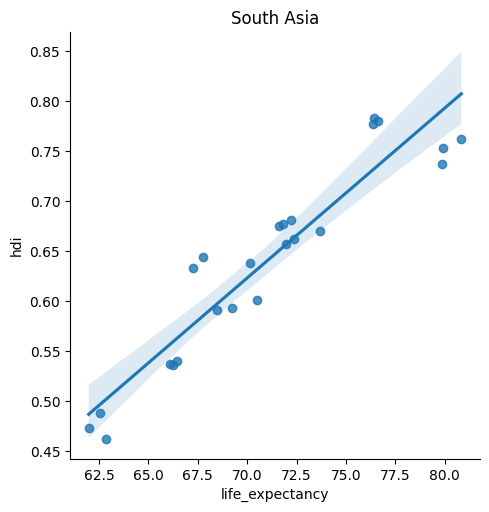

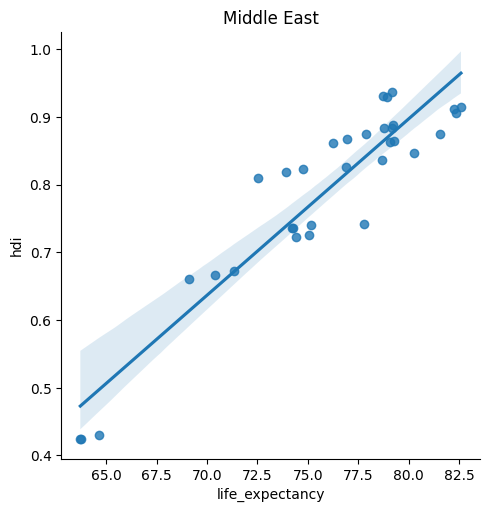

In [36]:
for region, data in {
    "South Asia": south_asia_2020_22,
    "Middle East": middle_east_2020_22
}.items():
    sns.lmplot(data=data, x='life_expectancy', y='hdi')
    plt.title(region)

##TASK 7: Outlier Detection

In [37]:
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

sa_outliers = find_outliers(south_asia_2020_22, 'hdi')
me_outliers = find_outliers(middle_east_2020_22, 'hdi')


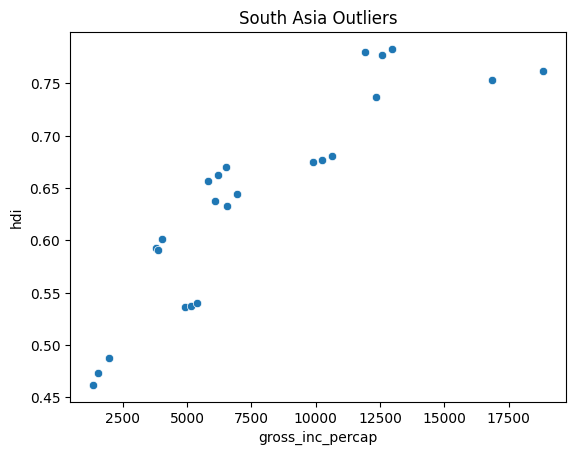

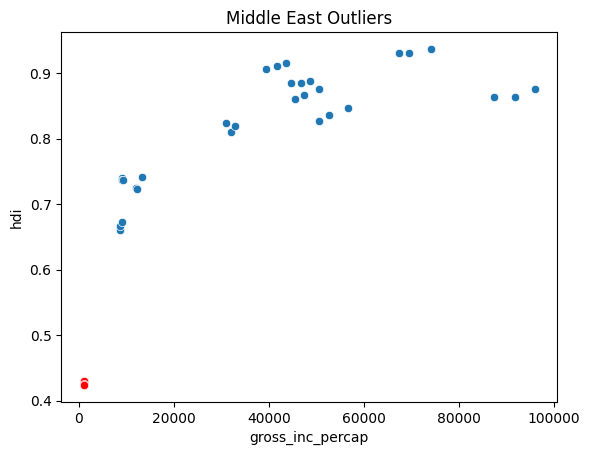

In [38]:
sns.scatterplot(data=south_asia_2020_22,
                x='gross_inc_percap', y='hdi')
sns.scatterplot(data=sa_outliers,
                x='gross_inc_percap', y='hdi', color='red')
plt.title("South Asia Outliers")
plt.show()

sns.scatterplot(data=middle_east_2020_22,
                x='gross_inc_percap', y='hdi')
sns.scatterplot(data=me_outliers,
                x='gross_inc_percap', y='hdi', color='red')
plt.title("Middle East Outliers")
plt.show()